In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.time import Time
from astropy.coordinates import SkyCoord
import astropy.units as u

from scipy.integrate import quad

In [2]:
base_dir = "/mnt/c/Users/david/Downloads/LIV_multiGRB"

grbs = [
    {
        "GRB": "GRB080916C",
        "trigger_utc": "2008-09-16 00:12:45.000",
        "ra_deg": 121.8,
        "dec_deg": -61.3,
        "z": 4.35,
    },
    {
        "GRB": "GRB090510",
        "trigger_utc": "2009-05-10 00:22:59.971",
        "ra_deg": 333.6,
        "dec_deg": -26.6,
        "z": 0.903,
    },
    {
        "GRB": "GRB090902B",
        "trigger_utc": "2009-09-02 11:05:08.310",
        "ra_deg": 265.0,
        "dec_deg": 27.33,
        "z": 1.822,
    },
    {
        "GRB": "GRB090926A",
        "trigger_utc": "2009-09-26 04:20:26.000",
        "ra_deg": 353.4,
        "dec_deg": -66.32,
        "z": 2.1062,
    },
    {
        "GRB": "GRB130427A",
        "trigger_utc": "2013-04-27 07:47:06.000",
        "ra_deg": 173.1367,
        "dec_deg": 27.6989,
        "z": 0.34,
    },
]

sample_df = pd.DataFrame(grbs)
sample_df

,GRB,trigger_utc,ra_deg,dec_deg,z
0,GRB080916C,2008-09-16 00:12:45.000,121.8000,-61.3000,4.3500
1,GRB090510,2009-05-10 00:22:59.971,333.6000,-26.6000,0.9030
2,GRB090902B,2009-09-02 11:05:08.310,265.0000,27.3300,1.8220
3,GRB090926A,2009-09-26 04:20:26.000,353.4000,-66.3200,2.1062
4,GRB130427A,2013-04-27 07:47:06.000,173.1367,27.6989,0.3400


In [3]:
for grb in grbs:
    folder = os.path.join(base_dir, grb["GRB"])
    print("\n", grb["GRB"])
    print("Folder exists:", os.path.exists(folder))
    
    if os.path.exists(folder):
        print(os.listdir(folder))


 GRB080916C
Folder exists: True
['.ipynb_checkpoints', 'L2605030822081A80259826_PH00.fits', 'L2605030822081A80259826_SC00.fits']

 GRB090510
Folder exists: True
['L2605030701551A80259815_PH00.fits', 'L2605030701551A80259815_SC00.fits', 'liv_env', 'w3browse-27365171', 'w3browse-27365171.tar']

 GRB090902B
Folder exists: True
['L2605030831271A80259806_PH00.fits', 'L2605030831271A80259806_SC00.fits']

 GRB090926A
Folder exists: True
['L260503084628F357373F61_PH00.fits', 'L260503084628F357373F61_SC00.fits']

 GRB130427A
Folder exists: True
['L2605030849011A80259898_PH00.fits', 'L2605030849011A80259898_SC00.fits']


In [4]:
def fermi_met_from_utc(utc_string):
    """
    Approximate Fermi Mission Elapsed Time:
    seconds since 2001-01-01 00:00:00 UTC.
    
    For publication, timing should later be verified against Fermi tools,
    but this is sufficient for first-pass analysis.
    """
    t = Time(utc_string, scale="utc")
    t0 = Time("2001-01-01 00:00:00", scale="utc")
    return t.unix - t0.unix

In [5]:
all_results = []

for grb in grbs:
    grb_folder = os.path.join(base_dir, grb["GRB"])
    photon_files = [f for f in os.listdir(grb_folder) if f.endswith("_PH00.fits")]
    
    if len(photon_files) == 0:
        print(f"No photon file found for {grb['GRB']}")
        continue
    
    photon_file = os.path.join(grb_folder, photon_files[0])
    print(f"Reading {grb['GRB']}: {photon_file}")

    with fits.open(photon_file) as hdul:
        events = hdul["EVENTS"].data

        time = np.asarray(events["TIME"], dtype=float).ravel()
        energy = np.asarray(events["ENERGY"], dtype=float).ravel()
        ra = np.asarray(events["RA"], dtype=float).ravel()
        dec = np.asarray(events["DEC"], dtype=float).ravel()
        zenith = np.asarray(events["ZENITH_ANGLE"], dtype=float).ravel()

    trigger_met = fermi_met_from_utc(grb["trigger_utc"])
    dt = time - trigger_met
    energy_gev = energy / 1000.0

    grb_coord = SkyCoord(ra=grb["ra_deg"] * u.deg, dec=grb["dec_deg"] * u.deg)
    photon_coord = SkyCoord(ra=ra * u.deg, dec=dec * u.deg)
    sep = grb_coord.separation(photon_coord).deg

    mask = (
        (dt >= 0) &
        (dt <= 10000) &
        (energy >= 100) &
        (zenith < 100) &
        (sep <= 12)
    )

    if mask.sum() == 0:
        print(f"No selected photons for {grb['GRB']}")
        continue

    idx_candidates = np.where(mask)[0]
    best_idx = idx_candidates[np.argmax(energy[idx_candidates])]

    all_results.append({
        "GRB": grb["GRB"],
        "z": grb["z"],
        "trigger_utc": grb["trigger_utc"],
        "photon_file": photon_file,
        "N_selected": int(mask.sum()),
        "Emax_MeV": energy[best_idx],
        "Emax_GeV": energy_gev[best_idx],
        "dt_s": dt[best_idx],
        "dt_rest_s": dt[best_idx] / (1 + grb["z"]),
        "photon_RA": ra[best_idx],
        "photon_DEC": dec[best_idx],
        "sep_deg": sep[best_idx],
        "ZENITH_ANGLE": zenith[best_idx],
    })

results_df = pd.DataFrame(all_results)
results_df

Reading GRB080916C: /mnt/c/Users/david/Downloads/LIV_multiGRB/GRB080916C/L2605030822081A80259826_PH00.fits
Reading GRB090510: /mnt/c/Users/david/Downloads/LIV_multiGRB/GRB090510/L2605030701551A80259815_PH00.fits
Reading GRB090902B: /mnt/c/Users/david/Downloads/LIV_multiGRB/GRB090902B/L2605030831271A80259806_PH00.fits
Reading GRB090926A: /mnt/c/Users/david/Downloads/LIV_multiGRB/GRB090926A/L260503084628F357373F61_PH00.fits
Reading GRB130427A: /mnt/c/Users/david/Downloads/LIV_multiGRB/GRB130427A/L2605030849011A80259898_PH00.fits


,GRB,z,trigger_utc,photon_file,N_selected,Emax_MeV,Emax_GeV,dt_s,dt_rest_s,photon_RA,photon_DEC,sep_deg,ZENITH_ANGLE
0,GRB080916C,4.3500,2008-09-16 00:12:45.000,/mnt/c/Users/david/Downloads/LIV_multiGRB/GRB0...,283,27428.804688,27.428805,42.122452,7.873355,119.840271,-56.721382,4.687936,83.471138
1,GRB090510,0.9030,2009-05-10 00:22:59.971,/mnt/c/Users/david/Downloads/LIV_multiGRB/GRB0...,248,29914.779297,29.914779,2.828319,1.486242,333.577454,-26.631203,0.037147,52.335388
2,GRB090902B,1.8220,2009-09-02 11:05:08.310,/mnt/c/Users/david/Downloads/LIV_multiGRB/GRB0...,450,39881.582031,39.881582,83.749104,29.677216,263.604218,28.653032,1.808129,44.646160
3,GRB090926A,2.1062,2009-09-26 04:20:26.000,/mnt/c/Users/david/Downloads/LIV_multiGRB/GRB0...,66,10418.358398,10.418358,3788.040679,1219.509587,353.391693,-66.284561,0.035596,61.946556
4,GRB130427A,0.3400,2013-04-27 07:47:06.000,/mnt/c/Users/david/Downloads/LIV_multiGRB/GRB1...,600,94116.390625,94.116391,246.549660,183.992283,173.095016,27.688919,0.038234,76.750359


In [6]:
results_df[[
    "GRB",
    "z",
    "N_selected",
    "Emax_GeV",
    "dt_s",
    "sep_deg",
    "ZENITH_ANGLE"
]]

,GRB,z,N_selected,Emax_GeV,dt_s,sep_deg,ZENITH_ANGLE
0,GRB080916C,4.3500,283,27.428805,42.122452,4.687936,83.471138
1,GRB090510,0.9030,248,29.914779,2.828319,0.037147,52.335388
2,GRB090902B,1.8220,450,39.881582,83.749104,1.808129,44.646160
3,GRB090926A,2.1062,66,10.418358,3788.040679,0.035596,61.946556
4,GRB130427A,0.3400,600,94.116391,246.549660,0.038234,76.750359


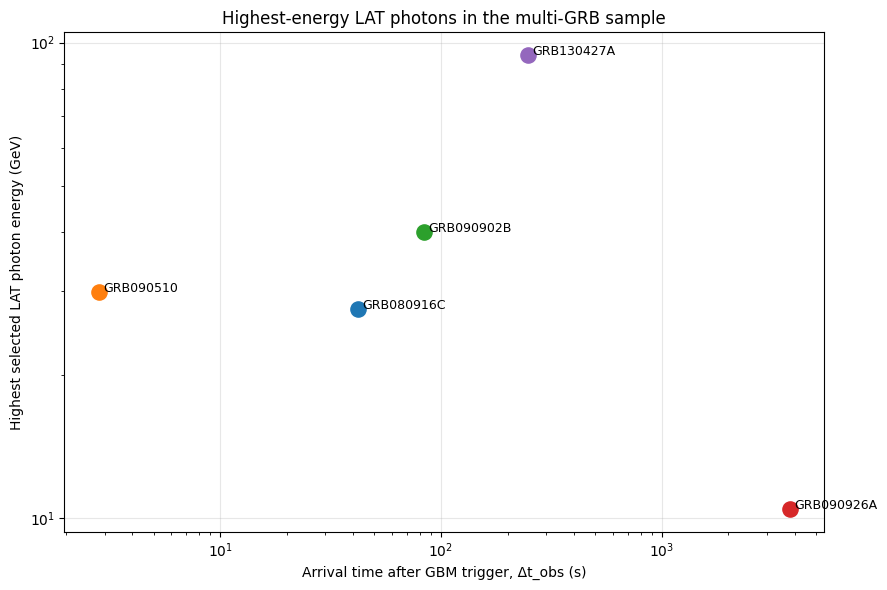

In [7]:
plt.figure(figsize=(9, 6))

for _, row in results_df.iterrows():
    plt.scatter(row["dt_s"], row["Emax_GeV"], s=120)
    plt.text(row["dt_s"] * 1.05, row["Emax_GeV"], row["GRB"], fontsize=9)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Arrival time after GBM trigger, Δt_obs (s)")
plt.ylabel("Highest selected LAT photon energy (GeV)")
plt.title("Highest-energy LAT photons in the multi-GRB sample")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("multi_grb_highest_photons_energy_time.png", dpi=250)
plt.show()

In [8]:
results_df.to_csv("multi_grb_highest_energy_photons_12deg.csv", index=False)
print("Saved multi_grb_highest_energy_photons_12deg.csv")

Saved multi_grb_highest_energy_photons_12deg.csv


In [9]:
# Cosmology
H0_km_s_Mpc = 70.0
Omega_m = 0.3
Omega_L = 0.7

Mpc_km = 3.0856775814913673e19
H0_s = H0_km_s_Mpc / Mpc_km

def liv_integral(z, n):
    integrand = lambda zp: ((1 + zp) ** n) / np.sqrt(Omega_m * (1 + zp) ** 3 + Omega_L)
    value, _ = quad(integrand, 0, z)
    return value

def eqg_limit(Eh_GeV, dt_s, z, n):
    """
    Conservative lower limit on E_QG,n.
    Assumes E_low << E_high.
    """
    if dt_s <= 0:
        return np.nan
    
    I_n = liv_integral(z, n)
    factor = ((1 + n) / (2 * H0_s)) * (Eh_GeV ** n) * I_n / dt_s
    return factor ** (1 / n)

liv_rows = []

for _, row in results_df.iterrows():
    liv_rows.append({
        "GRB": row["GRB"],
        "z": row["z"],
        "Emax_GeV": row["Emax_GeV"],
        "dt_s": row["dt_s"],
        "sep_deg": row["sep_deg"],
        "E_QG_1_lower_GeV": eqg_limit(row["Emax_GeV"], row["dt_s"], row["z"], n=1),
        "E_QG_2_lower_GeV": eqg_limit(row["Emax_GeV"], row["dt_s"], row["z"], n=2),
    })

liv_df = pd.DataFrame(liv_rows)

E_planck_GeV = 1.2209e19
liv_df["E_QG_1_in_EPlanck"] = liv_df["E_QG_1_lower_GeV"] / E_planck_GeV
liv_df["E_QG_2_TeV"] = liv_df["E_QG_2_lower_GeV"] / 1e3

liv_df

,GRB,z,Emax_GeV,dt_s,sep_deg,E_QG_1_lower_GeV,E_QG_2_lower_GeV,E_QG_1_in_EPlanck,E_QG_2_TeV
0,GRB080916C,4.3500,27.428805,42.122452,4.687936,1.227841e+18,1.236868e+10,0.100569,1.236868e+07
1,GRB090510,0.9030,29.914779,2.828319,0.037147,4.708423e+18,1.756428e+10,0.385652,1.756428e+07
2,GRB090902B,1.8220,39.881582,83.749104,1.808129,4.228671e+17,6.944187e+09,0.034636,6.944187e+06
3,GRB090926A,2.1062,10.418358,3788.040679,0.035596,2.792352e+15,2.982714e+08,0.000229,2.982714e+05
4,GRB130427A,0.3400,94.116391,246.549660,0.038234,6.132355e+16,3.187040e+09,0.005023,3.187040e+06


In [10]:
liv_df.to_csv("multi_grb_liv_limits_12deg_first_pass.csv", index=False)
print("Saved multi_grb_liv_limits_12deg_first_pass.csv")

Saved multi_grb_liv_limits_12deg_first_pass.csv


In [11]:
angular_cuts = [1, 3, 5, 12]

robust_rows = []

for grb in grbs:
    grb_folder = os.path.join(base_dir, grb["GRB"])
    photon_files = [f for f in os.listdir(grb_folder) if f.endswith("_PH00.fits")]
    photon_file = os.path.join(grb_folder, photon_files[0])

    with fits.open(photon_file) as hdul:
        events = hdul["EVENTS"].data

        time = np.asarray(events["TIME"], dtype=float).ravel()
        energy = np.asarray(events["ENERGY"], dtype=float).ravel()
        ra = np.asarray(events["RA"], dtype=float).ravel()
        dec = np.asarray(events["DEC"], dtype=float).ravel()
        zenith = np.asarray(events["ZENITH_ANGLE"], dtype=float).ravel()

    trigger_met = fermi_met_from_utc(grb["trigger_utc"])
    dt = time - trigger_met
    energy_gev = energy / 1000.0

    grb_coord = SkyCoord(ra=grb["ra_deg"] * u.deg, dec=grb["dec_deg"] * u.deg)
    photon_coord = SkyCoord(ra=ra * u.deg, dec=dec * u.deg)
    sep = grb_coord.separation(photon_coord).deg

    for cut in angular_cuts:
        mask = (
            (dt >= 0) &
            (dt <= 10000) &
            (energy >= 100) &
            (zenith < 100) &
            (sep <= cut)
        )

        if mask.sum() == 0:
            robust_rows.append({
                "GRB": grb["GRB"],
                "z": grb["z"],
                "angular_cut_deg": cut,
                "N_selected": 0,
                "Emax_GeV": np.nan,
                "dt_s": np.nan,
                "sep_deg": np.nan,
                "ZENITH_ANGLE": np.nan,
            })
            continue

        idx_candidates = np.where(mask)[0]
        best_idx = idx_candidates[np.argmax(energy[idx_candidates])]

        robust_rows.append({
            "GRB": grb["GRB"],
            "z": grb["z"],
            "angular_cut_deg": cut,
            "N_selected": int(mask.sum()),
            "Emax_GeV": energy_gev[best_idx],
            "dt_s": dt[best_idx],
            "dt_rest_s": dt[best_idx] / (1 + grb["z"]),
            "photon_RA": ra[best_idx],
            "photon_DEC": dec[best_idx],
            "sep_deg": sep[best_idx],
            "ZENITH_ANGLE": zenith[best_idx],
        })

robust_df = pd.DataFrame(robust_rows)

robust_df[[
    "GRB",
    "angular_cut_deg",
    "N_selected",
    "Emax_GeV",
    "dt_s",
    "sep_deg",
    "ZENITH_ANGLE"
]]

,GRB,angular_cut_deg,N_selected,Emax_GeV,dt_s,sep_deg,ZENITH_ANGLE
0,GRB080916C,1,2,1.204118,1448.594676,0.785037,87.413033
1,GRB080916C,3,19,1.894962,1920.809364,1.560301,91.320396
2,GRB080916C,5,126,27.428805,42.122452,4.687936,83.471138
3,GRB080916C,12,283,27.428805,42.122452,4.687936,83.471138
4,GRB090510,1,84,29.914779,2.828319,0.037147,52.335388
5,GRB090510,3,146,29.914779,2.828319,0.037147,52.335388
6,GRB090510,5,185,29.914779,2.828319,0.037147,52.335388
7,GRB090510,12,248,29.914779,2.828319,0.037147,52.335388
8,GRB090902B,1,153,21.718441,333.905186,0.075585,59.153660
9,GRB090902B,3,286,39.881582,83.749104,1.808129,44.646160


In [12]:
robust_df.to_csv("multi_grb_angular_cut_robustness.csv", index=False)
print("Saved multi_grb_angular_cut_robustness.csv")

Saved multi_grb_angular_cut_robustness.csv


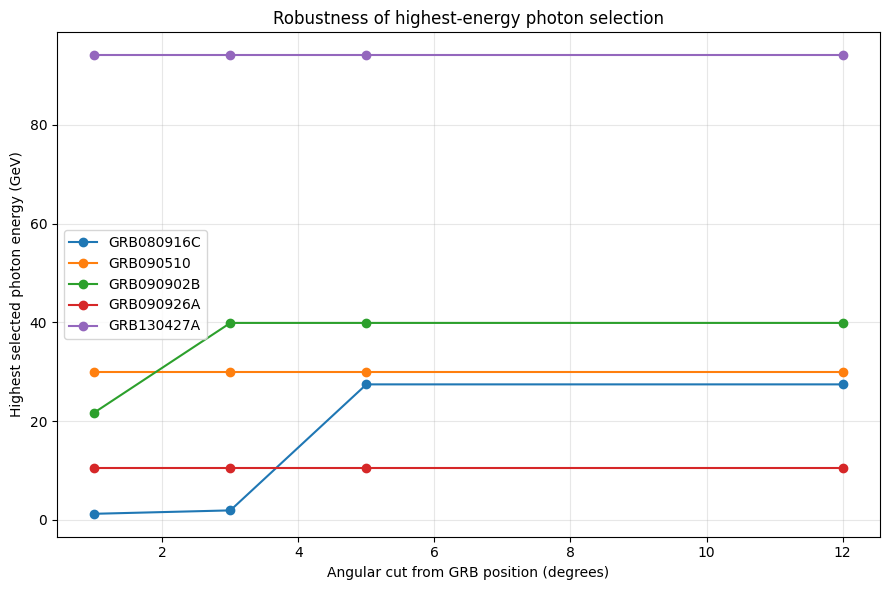

In [13]:
plt.figure(figsize=(9, 6))

for grb_name in robust_df["GRB"].unique():
    sub = robust_df[robust_df["GRB"] == grb_name]
    plt.plot(sub["angular_cut_deg"], sub["Emax_GeV"], marker="o", label=grb_name)

plt.xlabel("Angular cut from GRB position (degrees)")
plt.ylabel("Highest selected photon energy (GeV)")
plt.title("Robustness of highest-energy photon selection")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("angular_cut_robustness_Emax.png", dpi=250)
plt.show()

In [14]:
final_cut = 3

final_photon_df = robust_df[
    robust_df["angular_cut_deg"] == final_cut
].copy()

final_photon_df = final_photon_df.dropna(subset=["Emax_GeV", "dt_s"])

final_photon_df[[
    "GRB",
    "z",
    "angular_cut_deg",
    "N_selected",
    "Emax_GeV",
    "dt_s",
    "sep_deg",
    "ZENITH_ANGLE"
]]

,GRB,z,angular_cut_deg,N_selected,Emax_GeV,dt_s,sep_deg,ZENITH_ANGLE
1,GRB080916C,4.3500,3,19,1.894962,1920.809364,1.560301,91.320396
5,GRB090510,0.9030,3,146,29.914779,2.828319,0.037147,52.335388
9,GRB090902B,1.8220,3,286,39.881582,83.749104,1.808129,44.646160
13,GRB090926A,2.1062,3,9,10.418358,3788.040679,0.035596,61.946556
17,GRB130427A,0.3400,3,398,94.116391,246.549660,0.038234,76.750359


In [15]:
final_liv_rows = []

for _, row in final_photon_df.iterrows():
    final_liv_rows.append({
        "GRB": row["GRB"],
        "z": row["z"],
        "angular_cut_deg": row["angular_cut_deg"],
        "Emax_GeV": row["Emax_GeV"],
        "dt_s": row["dt_s"],
        "sep_deg": row["sep_deg"],
        "E_QG_1_lower_GeV": eqg_limit(row["Emax_GeV"], row["dt_s"], row["z"], n=1),
        "E_QG_2_lower_GeV": eqg_limit(row["Emax_GeV"], row["dt_s"], row["z"], n=2),
    })

final_liv_df = pd.DataFrame(final_liv_rows)

final_liv_df["E_QG_1_in_EPlanck"] = final_liv_df["E_QG_1_lower_GeV"] / E_planck_GeV
final_liv_df["E_QG_2_TeV"] = final_liv_df["E_QG_2_lower_GeV"] / 1e3

final_liv_df

,GRB,z,angular_cut_deg,Emax_GeV,dt_s,sep_deg,E_QG_1_lower_GeV,E_QG_2_lower_GeV,E_QG_1_in_EPlanck,E_QG_2_TeV
0,GRB080916C,4.3500,3,1.894962,1920.809364,1.560301,1.860223e+15,1.265411e+08,0.000152,1.265411e+05
1,GRB090510,0.9030,3,29.914779,2.828319,0.037147,4.708423e+18,1.756428e+10,0.385652,1.756428e+07
2,GRB090902B,1.8220,3,39.881582,83.749104,1.808129,4.228671e+17,6.944187e+09,0.034636,6.944187e+06
3,GRB090926A,2.1062,3,10.418358,3788.040679,0.035596,2.792352e+15,2.982714e+08,0.000229,2.982714e+05
4,GRB130427A,0.3400,3,94.116391,246.549660,0.038234,6.132355e+16,3.187040e+09,0.005023,3.187040e+06


In [16]:
final_photon_df.to_csv("final_photon_sample_3deg.csv", index=False)
final_liv_df.to_csv("final_liv_limits_3deg.csv", index=False)

print("Saved final_photon_sample_3deg.csv")
print("Saved final_liv_limits_3deg.csv")

Saved final_photon_sample_3deg.csv
Saved final_liv_limits_3deg.csv


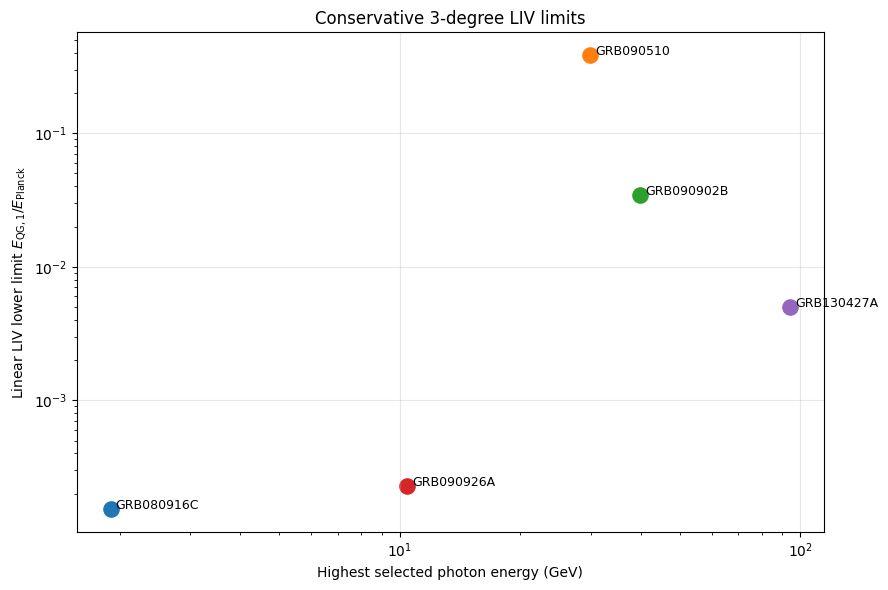

In [17]:
plt.figure(figsize=(9, 6))

for _, row in final_liv_df.iterrows():
    plt.scatter(row["Emax_GeV"], row["E_QG_1_in_EPlanck"], s=120)
    plt.text(row["Emax_GeV"] * 1.03, row["E_QG_1_in_EPlanck"], row["GRB"], fontsize=9)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Highest selected photon energy (GeV)")
plt.ylabel(r"Linear LIV lower limit $E_{\rm QG,1}/E_{\rm Planck}$")
plt.title("Conservative 3-degree LIV limits")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("final_liv_limits_3deg.png", dpi=250)
plt.show()

In [18]:
paper_table = final_liv_df[[
    "GRB",
    "z",
    "Emax_GeV",
    "dt_s",
    "sep_deg",
    "E_QG_1_lower_GeV",
    "E_QG_1_in_EPlanck",
    "E_QG_2_lower_GeV",
    "E_QG_2_TeV"
]].copy()

paper_table["Emax_GeV"] = paper_table["Emax_GeV"].round(3)
paper_table["dt_s"] = paper_table["dt_s"].round(3)
paper_table["sep_deg"] = paper_table["sep_deg"].round(4)
paper_table["E_QG_1_lower_GeV"] = paper_table["E_QG_1_lower_GeV"].map(lambda x: f"{x:.3e}")
paper_table["E_QG_1_in_EPlanck"] = paper_table["E_QG_1_in_EPlanck"].map(lambda x: f"{x:.3e}")
paper_table["E_QG_2_lower_GeV"] = paper_table["E_QG_2_lower_GeV"].map(lambda x: f"{x:.3e}")
paper_table["E_QG_2_TeV"] = paper_table["E_QG_2_TeV"].map(lambda x: f"{x:.3e}")

paper_table

,GRB,z,Emax_GeV,dt_s,sep_deg,E_QG_1_lower_GeV,E_QG_1_in_EPlanck,E_QG_2_lower_GeV,E_QG_2_TeV
0,GRB080916C,4.3500,1.895,1920.809,1.5603,1.860e+15,1.524e-04,1.265e+08,1.265e+05
1,GRB090510,0.9030,29.915,2.828,0.0371,4.708e+18,3.857e-01,1.756e+10,1.756e+07
2,GRB090902B,1.8220,39.882,83.749,1.8081,4.229e+17,3.464e-02,6.944e+09,6.944e+06
3,GRB090926A,2.1062,10.418,3788.041,0.0356,2.792e+15,2.287e-04,2.983e+08,2.983e+05
4,GRB130427A,0.3400,94.116,246.550,0.0382,6.132e+16,5.023e-03,3.187e+09,3.187e+06


In [19]:
paper_table.to_csv("paper_table_final_liv_3deg.csv", index=False)
print("Saved paper_table_final_liv_3deg.csv")

Saved paper_table_final_liv_3deg.csv


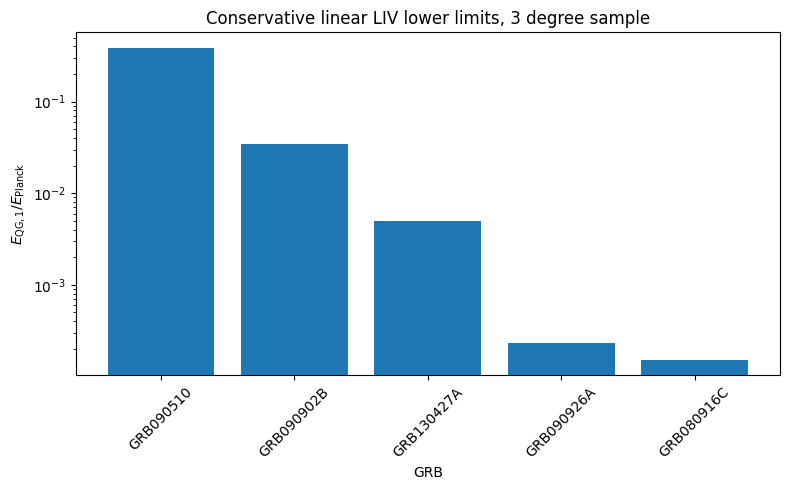

In [20]:
plt.figure(figsize=(8,5))

plot_df = final_liv_df.sort_values("E_QG_1_lower_GeV", ascending=False)

plt.bar(plot_df["GRB"], plot_df["E_QG_1_in_EPlanck"])
plt.yscale("log")
plt.ylabel(r"$E_{\rm QG,1}/E_{\rm Planck}$")
plt.xlabel("GRB")
plt.title("Conservative linear LIV lower limits, 3 degree sample")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("eqg1_limits_3deg_barplot.png", dpi=300)
plt.show()

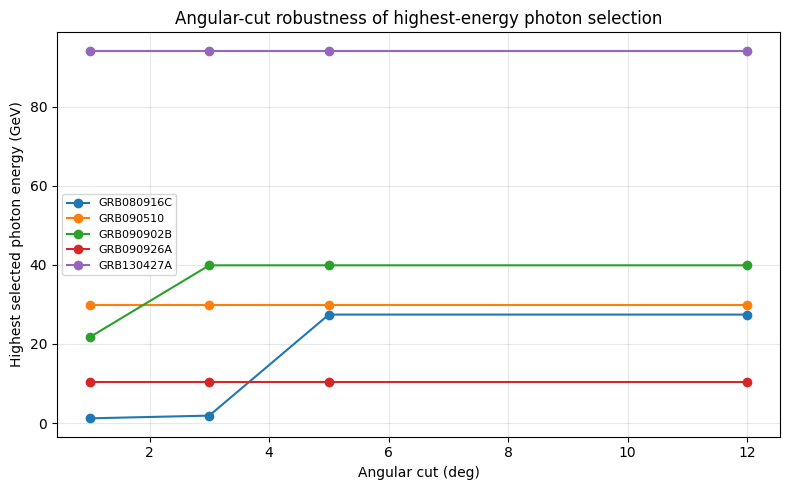

In [21]:
plt.figure(figsize=(8,5))

for grb_name in robust_df["GRB"].unique():
    sub = robust_df[robust_df["GRB"] == grb_name]
    plt.plot(sub["angular_cut_deg"], sub["Emax_GeV"], marker="o", label=grb_name)

plt.xlabel("Angular cut (deg)")
plt.ylabel("Highest selected photon energy (GeV)")
plt.title("Angular-cut robustness of highest-energy photon selection")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig("angular_cut_robustness_Emax.png", dpi=300)
plt.show()

In [22]:
final_photon_df.to_csv("final_photon_sample_3deg.csv", index=False)
final_liv_df.to_csv("final_liv_limits_3deg.csv", index=False)
robust_df.to_csv("multi_grb_angular_cut_robustness.csv", index=False)

print("All final CSV tables saved.")

All final CSV tables saved.


In [23]:
# ============================================
# Gold sample selection
# ============================================

gold_photon_df = final_photon_df[
    (final_photon_df["Emax_GeV"] >= 10) &
    (final_photon_df["dt_s"] <= 1000) &
    (final_photon_df["sep_deg"] <= 3) &
    (final_photon_df["ZENITH_ANGLE"] < 100)
].copy()

gold_photon_df[[
    "GRB",
    "z",
    "Emax_GeV",
    "dt_s",
    "sep_deg",
    "ZENITH_ANGLE"
]]

,GRB,z,Emax_GeV,dt_s,sep_deg,ZENITH_ANGLE
5,GRB090510,0.903,29.914779,2.828319,0.037147,52.335388
9,GRB090902B,1.822,39.881582,83.749104,1.808129,44.646160
17,GRB130427A,0.340,94.116391,246.549660,0.038234,76.750359


In [24]:
# Approximate T90 values in seconds.
# Later, verify these against the GBM catalog for final submission.
t90_map = {
    "GRB080916C": 66.0,
    "GRB090510": 0.960,
    "GRB090902B": 19.3,
    "GRB090926A": 20.0,
    "GRB130427A": 138.0,
}

final_photon_df["T90_s"] = final_photon_df["GRB"].map(t90_map)
gold_photon_df["T90_s"] = gold_photon_df["GRB"].map(t90_map)

final_photon_df[["GRB", "Emax_GeV", "dt_s", "T90_s", "sep_deg"]]

,GRB,Emax_GeV,dt_s,T90_s,sep_deg
1,GRB080916C,1.894962,1920.809364,66.00,1.560301
5,GRB090510,29.914779,2.828319,0.96,0.037147
9,GRB090902B,39.881582,83.749104,19.30,1.808129
13,GRB090926A,10.418358,3788.040679,20.00,0.035596
17,GRB130427A,94.116391,246.549660,138.00,0.038234


In [25]:
# ============================================
# Intrinsic-delay scenario analysis
# ============================================

def safe_delay(x, floor=1e-3):
    """
    Avoid zero or negative delay.
    """
    if pd.isna(x):
        return np.nan
    return max(float(x), floor)

scenario_rows = []

for _, row in final_photon_df.iterrows():
    dt_trigger = row["dt_s"]
    t90 = row["T90_s"]
    
    scenarios = {
        "A_trigger_reference": dt_trigger,
        "B_after_T90_reference": safe_delay(dt_trigger - t90),
        "C_rest_frame_diagnostic": dt_trigger / (1 + row["z"]),
    }
    
    for scenario_name, dt_eff in scenarios.items():
        scenario_rows.append({
            "GRB": row["GRB"],
            "scenario": scenario_name,
            "z": row["z"],
            "Emax_GeV": row["Emax_GeV"],
            "sep_deg": row["sep_deg"],
            "T90_s": t90,
            "dt_used_s": dt_eff,
            "E_QG_1_lower_GeV": eqg_limit(row["Emax_GeV"], dt_eff, row["z"], n=1),
            "E_QG_2_lower_GeV": eqg_limit(row["Emax_GeV"], dt_eff, row["z"], n=2),
        })

scenario_df = pd.DataFrame(scenario_rows)

E_planck_GeV = 1.2209e19
scenario_df["E_QG_1_in_EPlanck"] = scenario_df["E_QG_1_lower_GeV"] / E_planck_GeV
scenario_df["E_QG_2_TeV"] = scenario_df["E_QG_2_lower_GeV"] / 1e3

scenario_df[[
    "GRB",
    "scenario",
    "Emax_GeV",
    "dt_used_s",
    "E_QG_1_lower_GeV",
    "E_QG_1_in_EPlanck",
    "E_QG_2_lower_GeV"
]]

,GRB,scenario,Emax_GeV,dt_used_s,E_QG_1_lower_GeV,E_QG_1_in_EPlanck,E_QG_2_lower_GeV
0,GRB080916C,A_trigger_reference,1.894962,1920.809364,1.860223e+15,0.000152,1.265411e+08
1,GRB080916C,B_after_T90_reference,1.894962,1854.809364,1.926416e+15,0.000158,1.287728e+08
2,GRB080916C,C_rest_frame_diagnostic,1.894962,359.029788,9.952194e+15,0.000815,2.926903e+08
3,GRB090510,A_trigger_reference,29.914779,2.828319,4.708423e+18,0.385652,1.756428e+10
4,GRB090510,B_after_T90_reference,29.914779,1.868319,7.127756e+18,0.583812,2.161071e+10
5,GRB090510,C_rest_frame_diagnostic,29.914779,1.486242,8.960128e+18,0.733895,2.422979e+10
6,GRB090902B,A_trigger_reference,39.881582,83.749104,4.228671e+17,0.034636,6.944187e+09
7,GRB090902B,B_after_T90_reference,39.881582,64.449104,5.494994e+17,0.045008,7.915950e+09
8,GRB090902B,C_rest_frame_diagnostic,39.881582,29.677216,1.193331e+18,0.097742,1.166541e+10
9,GRB090926A,A_trigger_reference,10.418358,3788.040679,2.792352e+15,0.000229,2.982714e+08


In [26]:
gold_photon_df.to_csv("gold_photon_sample_3deg.csv", index=False)
scenario_df.to_csv("intrinsic_delay_scenario_limits.csv", index=False)

print("Saved gold_photon_sample_3deg.csv")
print("Saved intrinsic_delay_scenario_limits.csv")

Saved gold_photon_sample_3deg.csv
Saved intrinsic_delay_scenario_limits.csv


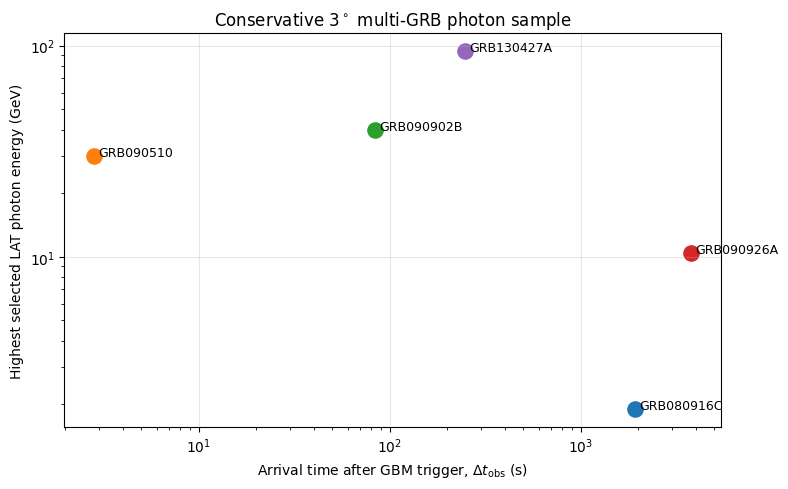

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

for _, row in final_photon_df.iterrows():
    plt.scatter(row["dt_s"], row["Emax_GeV"], s=120)
    plt.text(row["dt_s"]*1.05, row["Emax_GeV"], row["GRB"], fontsize=9)

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"Arrival time after GBM trigger, $\Delta t_{\rm obs}$ (s)")
plt.ylabel(r"Highest selected LAT photon energy (GeV)")
plt.title(r"Conservative $3^\circ$ multi-GRB photon sample")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("highest_photon_energy_time_3deg.png", dpi=300)
plt.show()

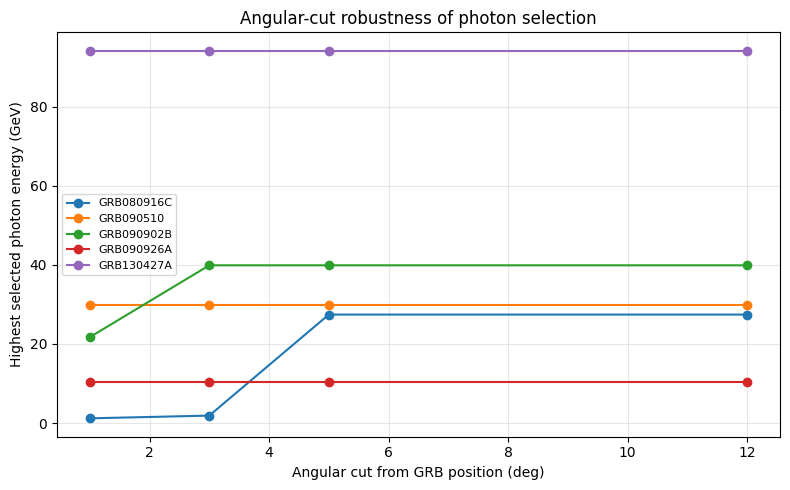

In [28]:
plt.figure(figsize=(8,5))

for grb_name in robust_df["GRB"].unique():
    sub = robust_df[robust_df["GRB"] == grb_name]
    plt.plot(sub["angular_cut_deg"], sub["Emax_GeV"], marker="o", label=grb_name)

plt.xlabel(r"Angular cut from GRB position (deg)")
plt.ylabel(r"Highest selected photon energy (GeV)")
plt.title(r"Angular-cut robustness of photon selection")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig("angular_cut_robustness_Emax.png", dpi=300)
plt.show()

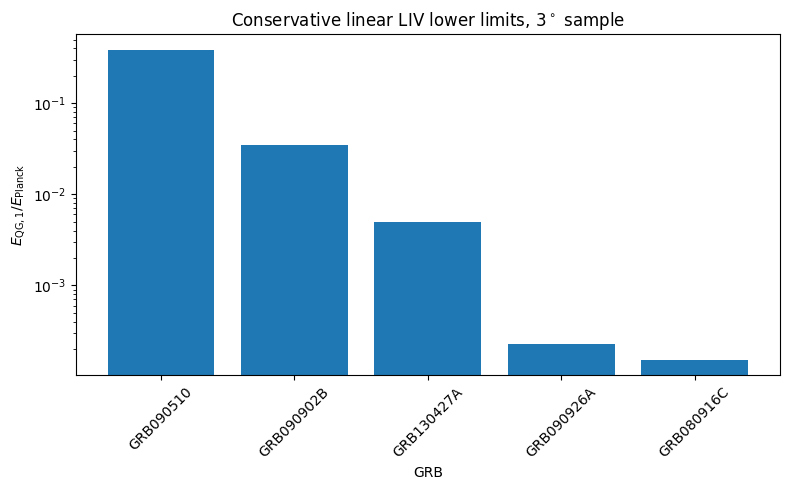

In [29]:
plot_df = final_liv_df.sort_values("E_QG_1_lower_GeV", ascending=False)

plt.figure(figsize=(8,5))
plt.bar(plot_df["GRB"], plot_df["E_QG_1_in_EPlanck"])
plt.yscale("log")
plt.ylabel(r"$E_{\rm QG,1}/E_{\rm Planck}$")
plt.xlabel("GRB")
plt.title(r"Conservative linear LIV lower limits, $3^\circ$ sample")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("eqg1_limits_3deg_barplot.png", dpi=300)
plt.show()

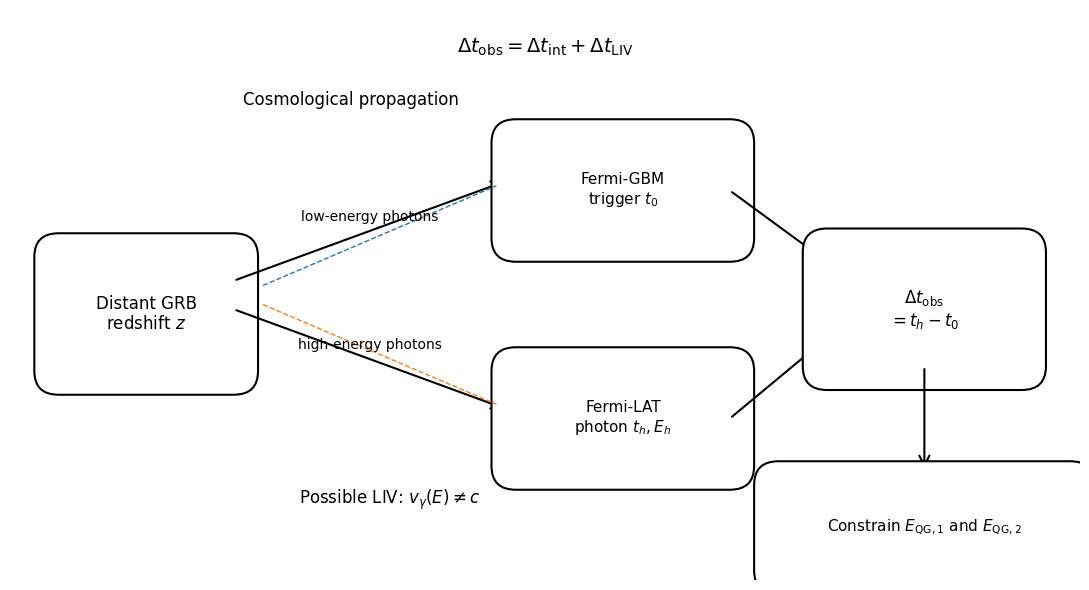

In [30]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Circle

fig, ax = plt.subplots(figsize=(11, 6))
ax.set_xlim(0, 11)
ax.set_ylim(0, 6)
ax.axis("off")

def box(x, y, w, h, text, fontsize=11):
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.25",
        linewidth=1.5,
        facecolor="white",
        edgecolor="black"
    )
    ax.add_patch(patch)
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=fontsize)
    return patch

def arrow(x1, y1, x2, y2, text=None, text_offset=0.15):
    arr = FancyArrowPatch(
        (x1, y1), (x2, y2),
        arrowstyle="->",
        mutation_scale=18,
        linewidth=1.5
    )
    ax.add_patch(arr)
    if text:
        ax.text((x1+x2)/2, (y1+y2)/2 + text_offset, text,
                ha="center", va="center", fontsize=10)

# Left: GRB source
grb = box(0.5, 2.2, 1.8, 1.2, "Distant GRB\nredshift $z$", fontsize=12)

# Photon propagation
arrow(2.3, 3.15, 5.1, 4.2, "low-energy photons")
arrow(2.3, 2.85, 5.1, 1.8, "high-energy photons")

# Middle: propagation region
ax.text(3.5, 5.0, "Cosmological propagation", ha="center", fontsize=12)
ax.plot([2.6, 5.0], [3.1, 4.15], linestyle="--", linewidth=1)
ax.plot([2.6, 5.0], [2.9, 1.85], linestyle="--", linewidth=1)
ax.text(3.9, 0.8, r"Possible LIV: $v_\gamma(E)\neq c$", ha="center", fontsize=12)

# Fermi detectors
gbm = box(5.2, 3.6, 2.2, 1.0, "Fermi-GBM\ntrigger $t_0$", fontsize=11)
lat = box(5.2, 1.2, 2.2, 1.0, "Fermi-LAT\nphoton $t_h, E_h$", fontsize=11)

# Delay computation
arrow(7.4, 4.1, 8.4, 3.35)
arrow(7.4, 1.7, 8.4, 2.55)

delay = box(8.4, 2.25, 2.0, 1.2, r"$\Delta t_{\rm obs}$" + "\n" + r"$=t_h-t_0$", fontsize=12)

# Constraint box
arrow(9.4, 2.25, 9.4, 1.15)
constraint = box(7.9, 0.1, 3.0, 0.9, r"Constrain $E_{\rm QG,1}$ and $E_{\rm QG,2}$", fontsize=11)

# Add equation at top
ax.text(
    5.5, 5.55,
    r"$\Delta t_{\rm obs}=\Delta t_{\rm int}+\Delta t_{\rm LIV}$",
    ha="center",
    fontsize=14
)

plt.tight_layout()
plt.savefig("schematic_grb_liv_workflow.png", dpi=300, bbox_inches="tight")
plt.show()

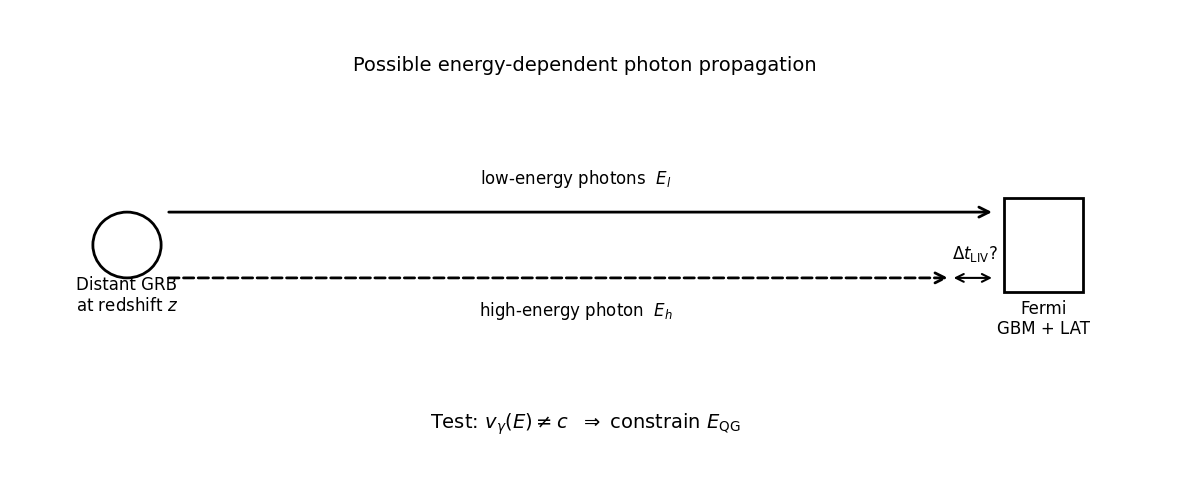

In [31]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch, Rectangle
import numpy as np

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_xlim(0, 12)
ax.set_ylim(0, 5)
ax.axis("off")

# GRB source
source = Circle((1.2, 2.5), 0.35, fill=False, linewidth=2)
ax.add_patch(source)
ax.text(1.2, 1.8, "Distant GRB\nat redshift $z$", ha="center", fontsize=12)

# Fermi satellite / detector
detector = Rectangle((10.2, 2.0), 0.8, 1.0, fill=False, linewidth=2)
ax.add_patch(detector)
ax.text(10.6, 1.55, "Fermi\nGBM + LAT", ha="center", fontsize=12)

# Low-energy photon path
ax.add_patch(FancyArrowPatch((1.6, 2.85), (10.1, 2.85),
                             arrowstyle="->", mutation_scale=18,
                             linewidth=2))
ax.text(5.8, 3.15, "low-energy photons  $E_l$", ha="center", fontsize=12)

# High-energy photon path, slightly lower
ax.add_patch(FancyArrowPatch((1.6, 2.15), (9.65, 2.15),
                             arrowstyle="->", mutation_scale=18,
                             linewidth=2,
                             linestyle="--"))
ax.text(5.8, 1.75, "high-energy photon  $E_h$", ha="center", fontsize=12)

# Delay gap
ax.add_patch(FancyArrowPatch((9.65, 2.15), (10.1, 2.15),
                             arrowstyle="<->", mutation_scale=14,
                             linewidth=1.5))
ax.text(9.9, 2.35, r"$\Delta t_{\rm LIV}$?", ha="center", fontsize=12)

# Labels
ax.text(5.9, 4.35, "Possible energy-dependent photon propagation", ha="center", fontsize=14)
ax.text(5.9, 0.55, r"Test: $v_\gamma(E)\neq c$  $\Rightarrow$ constrain $E_{\rm QG}$",
        ha="center", fontsize=14)

plt.tight_layout()
plt.savefig("diagram_grb_photon_propagation.png", dpi=300, bbox_inches="tight")
plt.show()

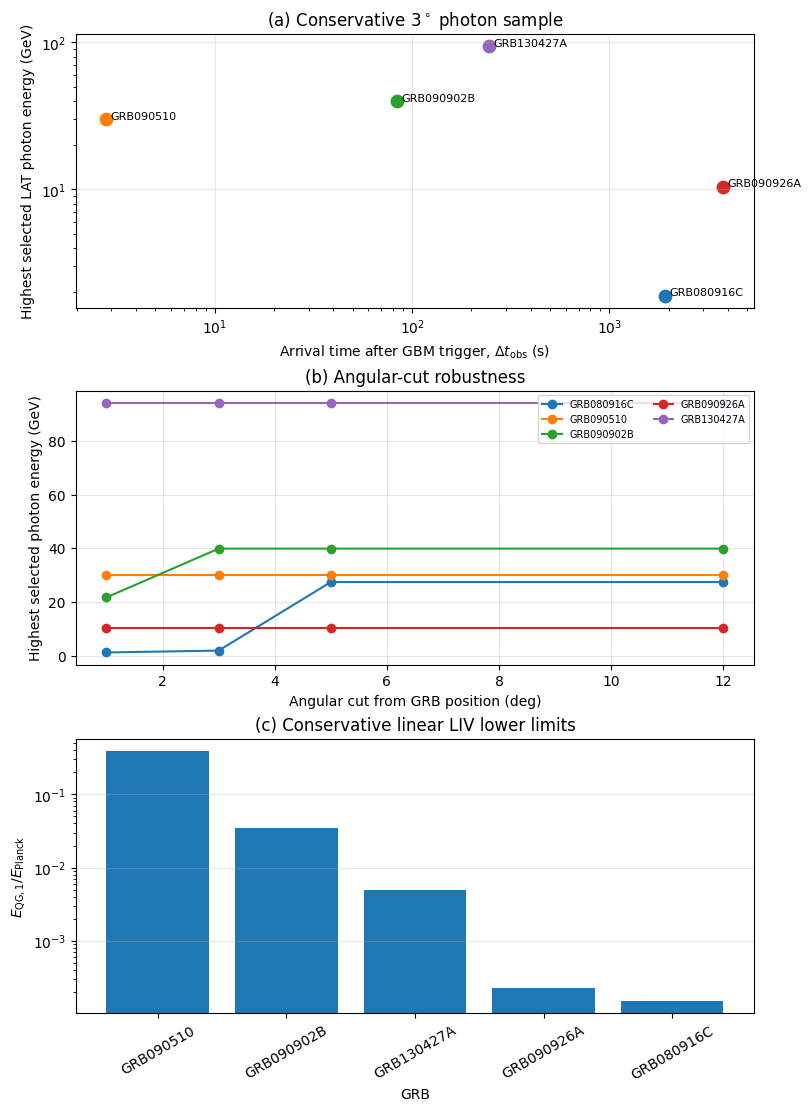

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# ==============================
# Multi-panel summary figure
# ==============================

fig, axes = plt.subplots(
    3, 1,
    figsize=(8, 11),
    constrained_layout=True
)

# ------------------------------
# Panel (a): Emax vs arrival time
# ------------------------------
ax = axes[0]

for _, row in final_photon_df.iterrows():
    ax.scatter(row["dt_s"], row["Emax_GeV"], s=80)
    ax.text(row["dt_s"] * 1.05, row["Emax_GeV"], row["GRB"], fontsize=8)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Arrival time after GBM trigger, $\Delta t_{\rm obs}$ (s)")
ax.set_ylabel(r"Highest selected LAT photon energy (GeV)")
ax.set_title(r"(a) Conservative $3^\circ$ photon sample")
ax.grid(True, alpha=0.3)


# ------------------------------
# Panel (b): angular robustness
# ------------------------------
ax = axes[1]

for grb_name in robust_df["GRB"].unique():
    sub = robust_df[robust_df["GRB"] == grb_name].sort_values("angular_cut_deg")
    ax.plot(
        sub["angular_cut_deg"],
        sub["Emax_GeV"],
        marker="o",
        linewidth=1.5,
        label=grb_name
    )

ax.set_xlabel(r"Angular cut from GRB position (deg)")
ax.set_ylabel(r"Highest selected photon energy (GeV)")
ax.set_title("(b) Angular-cut robustness")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=7, ncol=2)


# ------------------------------
# Panel (c): LIV limits
# ------------------------------
ax = axes[2]

plot_df = final_liv_df.sort_values("E_QG_1_in_EPlanck", ascending=False)

ax.bar(plot_df["GRB"], plot_df["E_QG_1_in_EPlanck"])
ax.set_yscale("log")
ax.set_ylabel(r"$E_{\rm QG,1}/E_{\rm Planck}$")
ax.set_xlabel("GRB")
ax.set_title(r"(c) Conservative linear LIV lower limits")
ax.tick_params(axis="x", rotation=30)
ax.grid(True, axis="y", alpha=0.3)

# Save
plt.savefig("figure_multigrb_liv_summary.png", dpi=300, bbox_inches="tight")
plt.show()